# MDR-TS v12.8
**Temporal-Station Soil Moisture Model + Shallow NN Baseline**

**Author:** Jakob Balkovec
**Affiliation:** Seattle University, Computer Science
**Project:** MDR
**Notebook Type:** Training, Evaluation, Baseline Modeling
**Last Updated:** Sat Feb 14th 2026

---

## Model Summary

- **Model Name:** MDR-TS
- **Version:** v12.8
- **Task:** Regression (Soil Moisture at 5 cm depth)
- **Target Variable:** `soil_moisture_5cm`
- **Temporal Resolution:** Daily

This notebook implements a clean baseline neural model:

1. **Shallow NN Baseline**
   A 2 to 3 layer mlp trained on the derived_new feature set with proper scaling, early stopping, and full evaluation.

Later notebooks may extend this with physics-residual correction and rain-focused modeling, but this notebook must remain a baseline.

---

## Reproducibility

- **Random Seed:** 42
- **Split Directory:** `data/splits/derived_new/`
- **Environment:** MacBook M2 Pro (local kernel)

---

## What’s New

- Imporving v12.7 with better feature selection and scaling, and a more robust training loop.
- Added artifact saving for predictions and metrics.
- Cleaned up notebook structure for clarity and reproducibility.


## 1. Imports + Environment Setup

In [17]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"using device: {device}")


using device: cpu


## 2. Features

In [18]:
split_dir = Path("/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new")
train_path = split_dir / "train_derived_new.csv"
val_path = split_dir / "val_derived_new.csv"
test_path = split_dir / "test_derived_new.csv"
meta_path = split_dir / "split_meta.json"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"missing split file: {p}")

if meta_path.exists():
    print(f"found optional metadata: {meta_path}")
else:
    print("optional split_meta.json not found; continuing without it")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "soil_moisture_5cm"
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if target_col not in df.columns:
        raise ValueError(f"{target_col} missing in {name} split")

train_df = train_df.dropna(subset=[target_col]).copy()
val_df = val_df.dropna(subset=[target_col]).copy()
test_df = test_df.dropna(subset=[target_col]).copy()

# drop obvious index junk
for df in [train_df, val_df, test_df]:
    junk = [c for c in df.columns if c.lower().startswith("unnamed")]
    if junk:
        df.drop(columns=junk, inplace=True)

exclude_cols = {
    target_col, "split", "fold", "station_id", "date", "timestamp", "path", "id"
}

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

sm_leak_cols = [c for c in feature_cols if c.startswith(f"{target_col}_lag")]
if sm_leak_cols:
    feature_cols = [c for c in feature_cols if c not in sm_leak_cols]
    print(f"removed {len(sm_leak_cols)} soil-moisture lag features: {sm_leak_cols[:5]}")

if not feature_cols:
    raise ValueError("no numeric feature columns were inferred")

# hard enforce shared feature set across splits
shared = set(feature_cols) & set(val_df.columns) & set(test_df.columns)
dropped = [c for c in feature_cols if c not in shared]
feature_cols = sorted(list(shared))

if not feature_cols:
    raise ValueError("no shared feature columns across train/val/test")

if dropped:
    print(f"dropped {len(dropped)} train-only numeric feature cols (not in all splits)")

# coerce to numeric, handle inf, compute medians on train only
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

train_medians = train_df[feature_cols].median()
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].fillna(train_medians)

print(f"train rows: {len(train_df):,} | val rows: {len(val_df):,} | test rows: {len(test_df):,}")
print(f"features: {len(feature_cols)}")

optional split_meta.json not found; continuing without it
train rows: 16,972 | val rows: 2,919 | test rows: 2,829
features: 353


In [19]:
def is_rain_feature(c: str) -> bool:
    s = c.lower()
    return ("rain" in s) or ("api" in s) or ("precip" in s) or ("ppt" in s)

rain_cols = [c for c in feature_cols if is_rain_feature(c)]
soil_cols = [c for c in feature_cols if c not in rain_cols]

soil_cols = sorted(soil_cols)
rain_cols = sorted(rain_cols)

if len(rain_cols) == 0:
    print("warning: no rain-like columns found...rain branch is gonna be weak")

print(f"rain features: {len(rain_cols)} | non-rain features: {len(soil_cols)}")

rain features: 43 | non-rain features: 310


## 3. Masking

In [20]:
gate_col = None
for c in ["G_rain_sum_7d", "G_API", "G_rain_sum_3d"]:
    if c in train_df.columns:
        gate_col = c
        break

wet_masks = None
wet_threshold = None

if gate_col is None:
    print("wet/dry reporting skipped: no gate column found")
else:
    for df in [train_df, val_df, test_df]:
        df[gate_col] = pd.to_numeric(df[gate_col], errors="coerce")
        df[gate_col] = df[gate_col].replace([np.inf, -np.inf], np.nan)

    if train_df[gate_col].isna().all():
        print(f"wet/dry skipped: {gate_col} is entirely NaN in train")
    else:
        wet_threshold = float(train_df[gate_col].quantile(0.90))
        print(f"wet/dry gate column: {gate_col}")
        print(f"wet threshold (train q0.90): {wet_threshold:.6f}")

wet/dry gate column: G_rain_sum_7d
wet threshold (train q0.90): 92.500000


In [21]:
required_cols = ["station_id"]
if "date" in train_df.columns:
    time_col = "date"
elif "timestamp" in train_df.columns:
    time_col = "timestamp"
else:
    raise ValueError("need date or timestamp for sequence modeling")

for df_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for c in required_cols + [time_col]:
        if c not in df.columns:
            raise ValueError(f"{c} missing in {df_name}")

for df in [train_df, val_df, test_df]:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

bad = int(train_df[time_col].isna().sum() + val_df[time_col].isna().sum() + test_df[time_col].isna().sum())
if bad > 0:
    raise ValueError(f"{time_col} has {bad} unparsable values")

train_df = train_df.sort_values(["station_id", time_col]).reset_index(drop=True)
val_df = val_df.sort_values(["station_id", time_col]).reset_index(drop=True)
test_df = test_df.sort_values(["station_id", time_col]).reset_index(drop=True)

print("sorted by station_id + time")

sorted by station_id + time


## 4. Scaling + Data Loaders

In [22]:
def build_seq_index(station_ids, dates, L, require_daily: bool):
    seq_ends = []
    n = len(dates)

    start = 0
    while start < n:
        sid = station_ids[start]
        end = start
        while end < n and station_ids[end] == sid:
            end += 1

        # indices [start, end) is one station
        if require_daily:
            seg_start = start
            for i in range(start + 1, end):
                dt = (dates[i] - dates[i - 1]) / np.timedelta64(1, "D")
                if not np.isfinite(dt) or dt > 1.5:
                    seg_end = i
                    for j in range(seg_start + (L - 1), seg_end):
                        seq_ends.append(j)
                    seg_start = i
            seg_end = end
            for j in range(seg_start + (L - 1), seg_end):
                seq_ends.append(j)
        else:
            for j in range(start + (L - 1), end):
                seq_ends.append(j)

        start = end

    return np.array(seq_ends, dtype=np.int64)

In [23]:
class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X_rows, y_rows, seq_ends, L, gate_rows=None, wet_thr=None):
        self.X = X_rows
        self.y = y_rows
        self.seq_ends = seq_ends
        self.L = L

        if gate_rows is not None and wet_thr is not None:
            self.is_wet = (gate_rows[seq_ends] >= wet_thr).astype(np.int64)
        else:
            self.is_wet = None

    def __len__(self):
        return len(self.seq_ends)

    def __getitem__(self, idx):
        end = int(self.seq_ends[idx])
        start = end - self.L + 1
        x_seq = self.X[start : end + 1]  # (L, F)
        y = self.y[end]  # scalar

        if self.is_wet is None:
            return torch.from_numpy(x_seq), torch.tensor([y], dtype=torch.float32)
        return torch.from_numpy(x_seq), torch.tensor([y], dtype=torch.float32), torch.tensor(self.is_wet[idx], dtype=torch.int64)

In [24]:
L = 14  # test 30
require_daily = True  # if true: sequences cannot cross date gaps

scaler = StandardScaler()
X_train_rows = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=np.float32)).astype(np.float32)
X_val_rows = scaler.transform(val_df[feature_cols].to_numpy(dtype=np.float32)).astype(np.float32)
X_test_rows = scaler.transform(test_df[feature_cols].to_numpy(dtype=np.float32)).astype(np.float32)

y_train_rows = train_df[target_col].to_numpy(dtype=np.float32)
y_val_rows = val_df[target_col].to_numpy(dtype=np.float32)
y_test_rows = test_df[target_col].to_numpy(dtype=np.float32)

In [25]:
dates_train = train_df[time_col].to_numpy()
dates_val = val_df[time_col].to_numpy()
dates_test = test_df[time_col].to_numpy()

sid_train = train_df["station_id"].to_numpy()
sid_val = val_df["station_id"].to_numpy()
sid_test = test_df["station_id"].to_numpy()

gate_train = train_df[gate_col].to_numpy() if gate_col is not None else None
gate_val = val_df[gate_col].to_numpy() if gate_col is not None else None
gate_test = test_df[gate_col].to_numpy() if gate_col is not None else None

train_seq_ends = build_seq_index(sid_train, dates_train, L=L, require_daily=require_daily)
val_seq_ends = build_seq_index(sid_val, dates_val, L=L, require_daily=require_daily)
test_seq_ends = build_seq_index(sid_test, dates_test, L=L, require_daily=require_daily)

print(f"seq length L={L} | train seq: {len(train_seq_ends):,} | val seq: {len(val_seq_ends):,} | test seq: {len(test_seq_ends):,}")

seq length L=14 | train seq: 16,019 | val seq: 2,599 | test seq: 2,580


In [26]:
train_ds = SeqDataset(X_train_rows, y_train_rows, train_seq_ends, L=L, gate_rows=gate_train, wet_thr=wet_threshold)
val_ds = SeqDataset(X_val_rows, y_val_rows, val_seq_ends, L=L, gate_rows=gate_val, wet_thr=wet_threshold)
test_ds = SeqDataset(X_test_rows, y_test_rows, test_seq_ends, L=L, gate_rows=gate_test, wet_thr=wet_threshold)

batch_size = 256 if len(train_ds) >= 50000 else 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"batch size: {batch_size}")
print(f"input dims: {X_train_rows.shape[1]}")

batch size: 128
input dims: 353


## 5. Model

In [27]:
d_model = 192
nhead = 6
num_layers = 3
ff_mult = 4
dropout_p = 0.1

class TemporalTransformerRegressor(nn.Module):
    def __init__(self, n_features: int, L: int):
        super().__init__()
        self.L = L
        self.in_proj = nn.Linear(n_features, d_model)

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos = nn.Parameter(torch.zeros(1, L + 1, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_mult * d_model,
            dropout=dropout_p,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(d_model // 2, 1),
        )

        self._init()

    def _init(self):
        nn.init.normal_(self.pos, mean=0.0, std=0.02)
        nn.init.normal_(self.cls, mean=0.0, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_seq):
        # x_seq: (B, L, F)
        x = self.in_proj(x_seq)  # (B, L, d)
        b = x.size(0)
        cls = self.cls.expand(b, -1, -1)  # (B, 1, d)
        x = torch.cat([cls, x], dim=1)  # (B, 1+L, d)
        x = x + self.pos[:, : x.size(1), :]
        x = self.encoder(x)
        cls_out = x[:, 0, :]
        return self.head(cls_out)

model = TemporalTransformerRegressor(n_features=X_train_rows.shape[1], L=L).to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

print(model)

TemporalTransformerRegressor(
  (in_proj): Linear(in_features=353, out_features=192, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (linear1): Linear(in_features=192, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=768, out_features=192, bias=True)
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=96, out_feature

/Users/jbalkovec/miniforge3/envs/dr-arm/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    threshold=1e-4,
    min_lr=5e-6,
    verbose=True,
)

## 6. Training Loop + Early Stopping

In [28]:
def safe_r2(y_true, y_pred):
    if y_true.size == 0:
        return np.nan
    if np.allclose(y_true, y_true[0]):
        return np.nan
    return float(r2_score(y_true, y_pred))

In [29]:
def gaussian_nll(mu, log_var, target):
    err2 = (target - mu) ** 2
    inv_var = torch.exp(-log_var)
    return torch.mean(0.5 * (inv_var * err2 + log_var))

In [30]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    y_true_chunks = []
    y_pred_chunks = []

    for batch in loader:
        if len(batch) == 2:
            x_seq, yb = batch
        else:
            x_seq, yb, _ = batch

        x_seq = x_seq.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            pred = model(x_seq)
            loss = criterion(pred, yb)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        y_true_chunks.append(yb.detach().cpu().numpy().reshape(-1))
        y_pred_chunks.append(pred.detach().cpu().numpy().reshape(-1))

    y_true_epoch = np.concatenate(y_true_chunks)
    y_pred_epoch = np.concatenate(y_pred_chunks)
    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, y_true_epoch, y_pred_epoch

In [31]:
max_epochs = 200
patience = 15
wait = 0
best_val_r2 = -np.inf
best_state = None

epoch_bar = tqdm(total=max_epochs, desc="training", leave=True, dynamic_ncols=True, mininterval=0.2)

for epoch in range(1, max_epochs + 1):
    train_loss, _, _ = run_epoch(train_loader, training=True)
    val_loss, y_val_true_epoch, y_val_pred_epoch = run_epoch(val_loader, training=False)

    val_r2 = safe_r2(y_val_true_epoch, y_val_pred_epoch)
    val_mae = float(mean_absolute_error(y_val_true_epoch, y_val_pred_epoch))
    val_rmse = float(np.sqrt(mean_squared_error(y_val_true_epoch, y_val_pred_epoch)))

    scheduler.step(val_r2)

    improved = np.isnan(best_val_r2) or (
        not np.isnan(val_r2) and (val_r2 > best_val_r2 + 1e-6)
    )

    if improved:
        best_val_r2 = val_r2
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    lr = optimizer.param_groups[0]["lr"]

    epoch_bar.update(1)
    epoch_bar.set_postfix(
        lr=f"{lr:.2e}",
        train_loss=f"{train_loss:.4f}",
        val_loss=f"{val_loss:.4f}",
        val_r2=f"{val_r2:.4f}",
        wait=wait,
    )
    epoch_bar.refresh()

    if wait >= patience:
        epoch_bar.close()
        print(f"early stopping at epoch {epoch}; best val_r2={best_val_r2:.6f}")
        break

if best_state is None:
    raise RuntimeError("training did not produce a valid checkpoint")

model.load_state_dict(best_state)
model.to(device)
print(f"restored best model with val_r2={best_val_r2:.6f}")

training:   0%|          | 0/200 [00:00<?, ?it/s]

early stopping at epoch 20; best val_r2=0.717331
restored best model with val_r2=0.717331


## 7. Evaluation

In [40]:
@torch.no_grad()
def predict_loader(loader):
    model.eval()
    preds = []
    trues = []
    wets = []

    for batch in loader:
        if len(batch) == 2:
            x_seq, yb = batch
            wet = None
        else:
            x_seq, yb, wet = batch

        x_seq = x_seq.to(device)
        pred = model(x_seq)

        preds.append(pred.detach().cpu().numpy().reshape(-1))
        trues.append(yb.detach().cpu().numpy().reshape(-1))
        if wet is not None:
            wets.append(wet.detach().cpu().numpy().reshape(-1))

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    is_wet = np.concatenate(wets) if len(wets) else None
    return y_true, y_pred, is_wet

In [41]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if y_true.size == 0:
        return {
            "r2": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "bias": np.nan,
            "medae": np.nan,
            "pearson": np.nan,
            "nrmse_range": np.nan,
            "nrmse_std": np.nan,
            "explained_var": np.nan,
            "mape": np.nan,
            "p90_abs_err": np.nan,
        }

    r2 = safe_r2(y_true, y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    bias = float(np.mean(y_pred - y_true))
    medae = float(np.median(np.abs(y_true - y_pred)))

    pearson = float(np.corrcoef(y_true, y_pred)[0, 1]) if y_true.size > 1 else np.nan

    y_range = float(np.max(y_true) - np.min(y_true))
    y_std = float(np.std(y_true))

    nrmse_range = rmse / y_range if y_range > 0 else np.nan
    nrmse_std = rmse / y_std if y_std > 0 else np.nan

    explained_var = 1.0 - np.var(y_true - y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan

    eps = 1e-6
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))))

    abs_err = np.abs(y_true - y_pred)
    p90_abs_err = float(np.percentile(abs_err, 90))

    return {
        "r2": r2,
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "medae": medae,
        "pearson": pearson,
        "nrmse_range": nrmse_range,
        "nrmse_std": nrmse_std,
        "explained_var": explained_var,
        "mape": mape,
        "p90_abs_err": p90_abs_err,
    }

In [42]:
metrics = {}
rows = []

for split_name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    y_true, y_pred, is_wet = predict_loader(loader)

    metrics[split_name] = {}

    m_overall = compute_metrics(y_true, y_pred)
    metrics[split_name]["overall"] = m_overall
    rows.append({"split": split_name, "subset": "overall", **m_overall})

    if is_wet is not None:
        mask_w = (is_wet == 1)
        mask_d = ~mask_w

        m_wet = compute_metrics(y_true[mask_w], y_pred[mask_w])
        m_dry = compute_metrics(y_true[mask_d], y_pred[mask_d])

        metrics[split_name]["wet"] = m_wet
        metrics[split_name]["dry"] = m_dry

        rows.append({"split": split_name, "subset": "wet", **m_wet})
        rows.append({"split": split_name, "subset": "dry", **m_dry})

    if split_name == "test":
        abs_err = np.abs(y_true - y_pred)
        k = max(1, int(np.ceil(0.10 * len(abs_err))))
        worst_idx = np.argsort(abs_err)[-k:]

        m_worst = compute_metrics(y_true[worst_idx], y_pred[worst_idx])
        metrics[split_name]["worst_decile"] = m_worst
        rows.append({"split": split_name, "subset": "worst_decile", **m_worst})

summary_df = pd.DataFrame(rows)
main_cols = [
    "split",
    "subset",
    "r2",
    "mae",
    "rmse",
    "bias",
    "medae",
    "pearson",
    "nrmse_std",
    "explained_var",
    "p90_abs_err",
]
main_cols = [c for c in main_cols if c in summary_df.columns]

print(summary_df[main_cols].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

split       subset        r2      mae     rmse      bias    medae  pearson  nrmse_std  explained_var  p90_abs_err
train      overall  0.816063 0.033269 0.043739  0.004058 0.026292 0.904263   0.428879       0.817646     0.071448
train          wet  0.581960 0.030397 0.038044 -0.002145 0.025607 0.763918   0.646560       0.583289     0.063873
train          dry  0.813413 0.033589 0.044328  0.004749 0.026397 0.903174   0.431958       0.815554     0.072247
  val      overall  0.717331 0.042537 0.054118 -0.024003 0.034086 0.886070   0.531666       0.772937     0.089773
  val          wet -0.562983 0.042317 0.052401 -0.030745 0.035629 0.342736   1.250193      -0.024917     0.086195
  val          dry  0.722543 0.042564 0.054328 -0.023163 0.034063 0.887354   0.526741       0.772976     0.090547
 test      overall  0.676333 0.042941 0.053367 -0.007787 0.036303 0.827906   0.568918       0.683224     0.087631
 test          wet -1.896991 0.041978 0.049773 -0.033312 0.038519 0.324242   1.702055   

In [43]:
artifact_dir = Path("/Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.8/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pred_parts = []

for split_name, loader in [
    ("train", train_loader),
    ("val", val_loader),
    ("test", test_loader),
]:
    y_true_split, y_pred_split, is_wet_split = predict_loader(loader)

    data = {
        "split": split_name,
        "y_true": y_true_split,
        "y_pred": y_pred_split,
        "abs_err": np.abs(y_true_split - y_pred_split),
    }

    if is_wet_split is not None:
        data["is_wet"] = is_wet_split.astype(int)

    pred_parts.append(pd.DataFrame(data))

preds_df = pd.concat(pred_parts, ignore_index=True)

preds_path = artifact_dir / "preds_transformer_v12_8.csv"
metrics_path = artifact_dir / "metrics_transformer_v12_8.json"

preds_df.to_csv(preds_path, index=False)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved predictions: {preds_path}")
print(f"saved metrics: {metrics_path}")

saved predictions: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.8/artifacts/preds_transformer_v12_8.csv
saved metrics: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.8/artifacts/metrics_transformer_v12_8.json


## 8. Plots

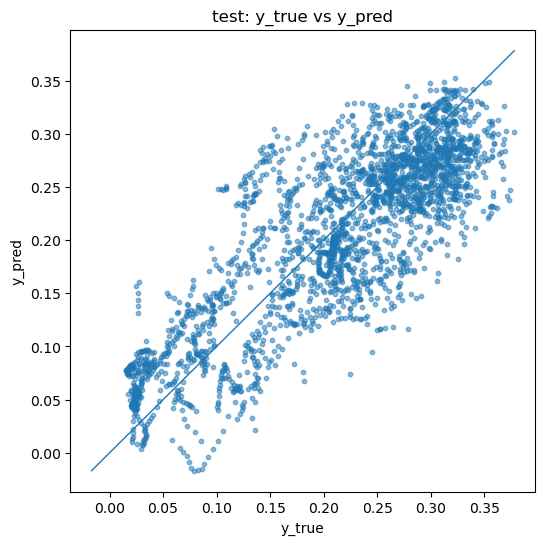

In [48]:
y_test_true, y_test_pred, _ = predict_loader(test_loader)

residuals_test = y_test_true - y_test_pred
abs_err_test = np.abs(residuals_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_true, y_test_pred, s=10, alpha=0.5)

min_v = float(min(y_test_true.min(), y_test_pred.min()))
max_v = float(max(y_test_true.max(), y_test_pred.max()))

ax.plot([min_v, max_v], [min_v, max_v], linewidth=1)
ax.set_xlabel("y_true")
ax.set_ylabel("y_pred")
ax.set_title("test: y_true vs y_pred")

plt.show()



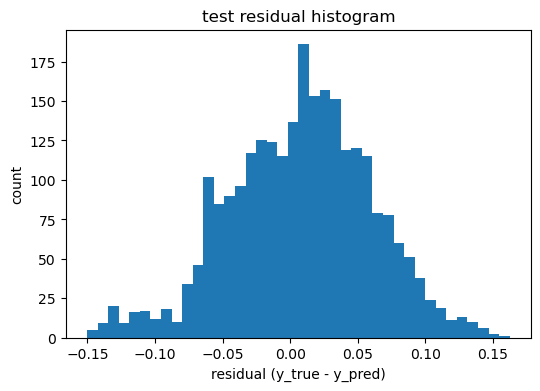

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals_test, bins=40)
ax.set_xlabel("residual (y_true - y_pred)")
ax.set_ylabel("count")
ax.set_title("test residual histogram")
plt.show()

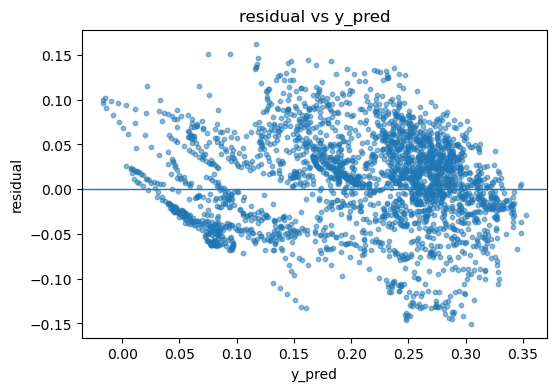

In [50]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred, residuals_test, s=10, alpha=0.5)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("y_pred")
ax.set_ylabel("residual")
ax.set_title("residual vs y_pred")
plt.show()